In [1]:
# Importamos as bibliotecas de manipulação de dados estruturados
import pandas as pd
import numpy as np

# Ferramenta para dividir os dados históricos de forma estratificada (mantendo a proporção de fraudes nas duas partes)
from sklearn.model_selection import train_test_split

# Importamos o algoritmo supervisionado Random Forest
from sklearn.ensemble import RandomForestClassifier

# Importamos os indicadores de desempenho e gráficos de avaliação financeira
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
# Buscamos a base histórica de transações
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# Isolamos as características de comportamento (X) e a resposta real de fraudes (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Separamos os dados em Treino e Teste de forma estratificada (stratify=y) para garantir fraudes em ambas as partes
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

In [3]:
# Instanciamos o classificador Random Forest fixando o estado aleatório para replicação
rf = RandomForestClassifier(random_state=42)

# O modelo estuda o histórico e aprende a separar o comportamento de uma compra comum de uma fraude
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



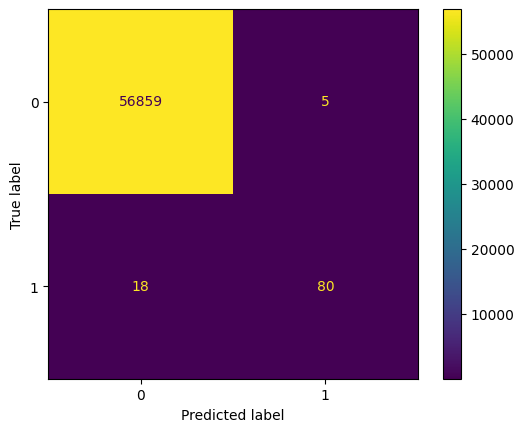

In [4]:
# O modelo faz as predições para a base de teste que ele nunca viu antes
y_pred_rf = rf.predict(X_test)

# Exibimos o relatório de performance (geralmente apresenta um Recall altíssimo perto dos anteriores)
print(classification_report(y_test, y_pred_rf))

# Geramos a Matriz de Confusão para visualizar graficamente os bloqueios corretos e eventuais falhas
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

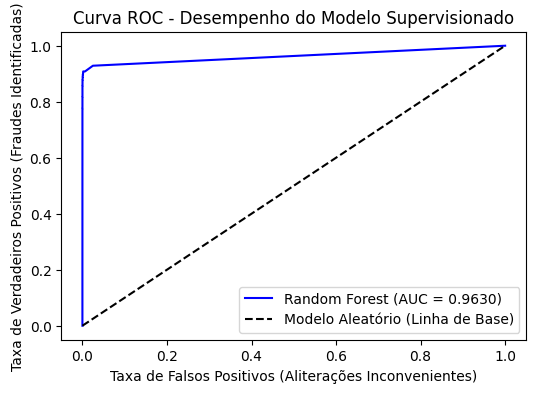

In [6]:
# Calculamos as probabilidades para gerar a curva estatística
y_pred_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Construímos o gráfico da Curva ROC para a apresentação executiva
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.4f})", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Modelo Aleatório (Linha de Base)")
plt.xlabel("Taxa de Falsos Positivos (Aliterações Inconvenientes)")
plt.ylabel("Taxa de Verdadeiros Positivos (Fraudes Identificadas)")
plt.title("Curva ROC - Desempenho do Modelo Supervisionado")
plt.legend(loc="lower right")

# LINHA NOVA: Salva o gráfico da curva ROC na pasta reports
plt.savefig("../reports/roc_curve.png", bbox_inches='tight', dpi=300)


plt.show()